# Computer Vision Exercise

The first block gets us ready to experience a little bit of computer vision analysis. You may have worked already with some of the packages, however there will be some new ones we want to explore!

In [1]:


import sys
print(sys.executable)

import numpy as np

import scipy
import imageio
import matplotlib.pyplot as plt  


c:\Users\Nutzer\Documents\programming scripts\uni\semester4\ai\ex7_computer_vision\.venv\Scripts\python.exe


# Image Processing Basics

## 1. Reading Images

For this section you'll need the image "parot.jpg" in your workspace. Make sure that the path is correct and the image exists. You may have to download it from CampUAS.


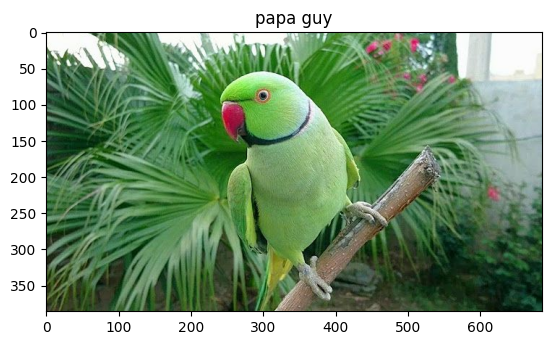

In [5]:
# Read an image
col_img = imageio.v2.imread('parot.jpg')

# Show the image 
plt.imshow(col_img)
plt.title("papa guy")
plt.show()


Images are stored as numpy arrays! 
Here get image size (height x width) in pixels and plot the red channel in grayscale!   

(386, 686, 3)
Width: 686, Height: 386


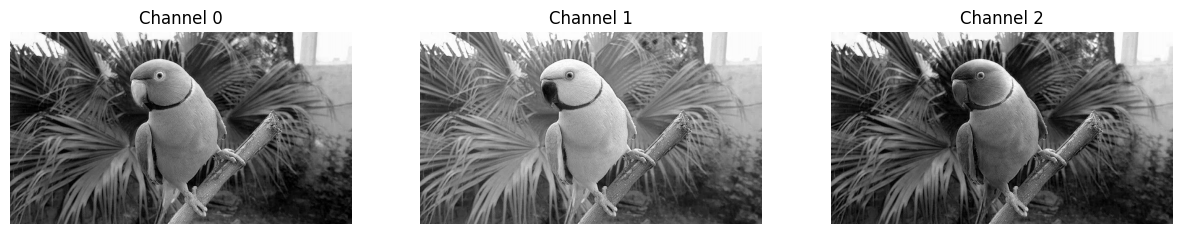

In [18]:
# Image size in pixels
print(col_img.shape)

height, width = col_img.shape[:2]
print(f"Width: {width}, Height: {height}")

# Red color channel --- please check with the original image !!!
# TASK: explore the other channels!


fig, axes = plt.subplots(1, 3, figsize=(15,5))

for i in range(3):
        
    axes[i].imshow(col_img[:,:,i], cmap='gray')
    axes[i].axis('off')
    axes[i].set_title(f"Channel {i}")

plt.show()



## 2. Simple Pointwise Manipulations 

Gray Scale Conversion

Transform the color image into a gray scale image using the luminance method.

The RGB channel weights are 0.299 * R + 0.587 * G + 0.114 * B.

The human eye is not equally sensitive to all three color. Therfore 
this method accounts for the perceptual differences of the human eye.

Compare the results to a gray scale image that takes the average across all three color channels.

What are your observations? 

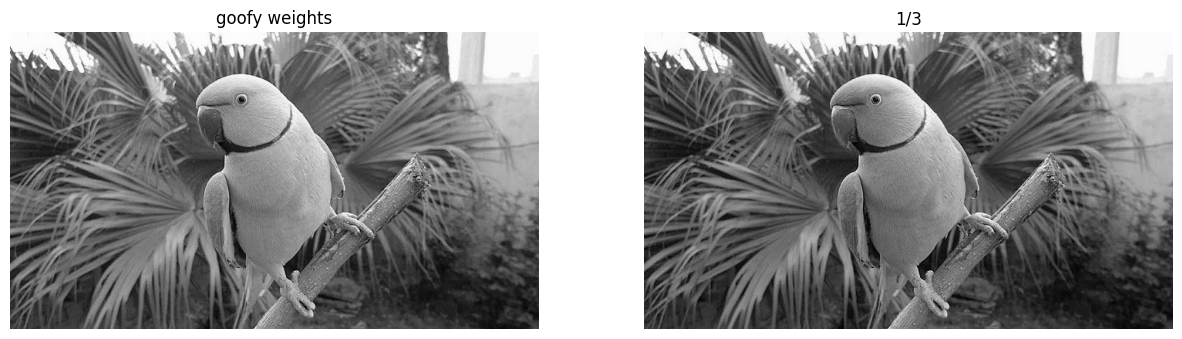

In [33]:
# Gray Scale Conversion
# For this task you may find the numpy dot product useful!

img=np.dot(col_img[...,:3], [0.299, 0.587, 0.114])
imgthird =  np.dot(col_img[...,:3], [1/3, 1/3, 1/3])
imgone = np.dot(col_img[...,:3], [1, 1, 1])

# TASK
# Add code for converting color image to gray 
# with balanced channels weighting 

fig, axes = plt.subplots(1, 2, figsize=(15,5))

axes[0].imshow(img, cmap="gray")
axes[0].set_title("goofy weights")

axes[1].imshow(imgthird, cmap="gray")
axes[1].set_title("1/3")



for ax in axes:
    ax.axis("off")



plt.show()


## 3. Saving images
Save the grey-scale image as 'gray-parot.jpg'

In [34]:
print(type(img))      
print(img.shape, img.dtype)

#convert image to 7 Bit integer
image = img.astype(np.uint8)
imageio.imwrite('parot-gray.jpg', image)


<class 'numpy.ndarray'>
(386, 686) float64


# Convolution and Filtering

For this section you'll need the image "Zebras-small.jpg" in your workspace. Make sure that the path is correct and the image exists. You may have to download it from CampUAS.

Import the image. What size is the image?


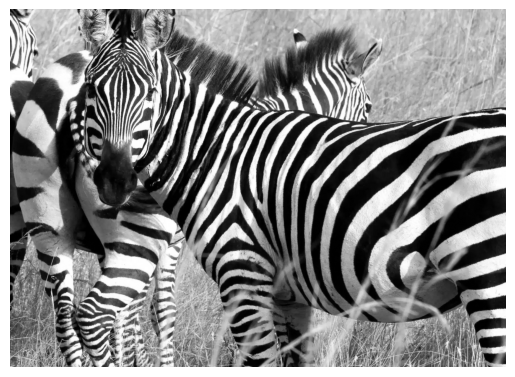

(1281, 1776)


In [36]:
zebras = imageio.v2.imread('Zebras-small.jpg')

# Show the image 
plt.imshow(zebras, cmap = 'gray')
plt.axis('off')
plt.show()

print(zebras.shape)


## 1. Low Pass Filtering -- Gaussian Smoothing

Use a Gaussion filter with different kernel sizes to eliminate high spatial frequencies from the image. 
Start with a small kernel first and increase the filter size step by step. What are your observations?


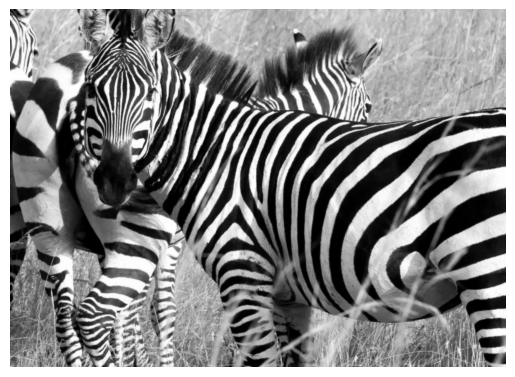

In [43]:
# TASK: explore differnt sigma values
#
smoothed_img = scipy.ndimage.gaussian_filter(zebras, sigma=1)
plt.imshow(smoothed_img, cmap='gray')
plt.axis('off')
plt.show()

## 2. Convolution
Use the convolution method to produce outputs. 

Define the Prewitt filters from the lecture and calculate the output using the convolve method.
Insepct your results!


Min: 0
Max: 255


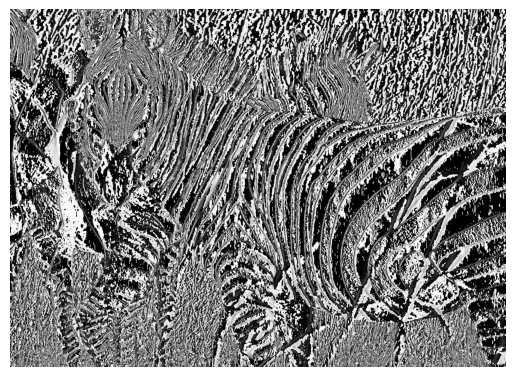

In [ ]:
prewitt_horizontal = np.array([
    [ 1, 0, -1],
    [ 1, 0, -1],
    [ 1, 0, -1]
])

horizontal_edges = scipy.ndimage.convolve(smoothed_img, prewitt_horizontal)

min_val = np.min(horizontal_edges)
max_val = np.max(horizontal_edges)

print("Min:", min_val)
print("Max:", max_val)

plt.imshow(horizontal_edges, cmap='gray')
plt.axis('off')
plt.show()


Min: 0
Max: 255


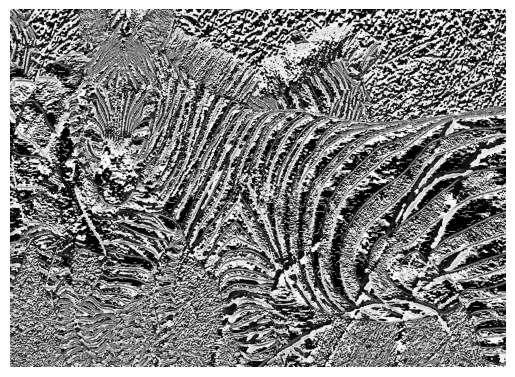

In [46]:
## TASK
# Add the horizontal filter matrix


prewitt_horizontal = np.array([
    [ 1, 1, 1],
    [ 0, 0, 0],
    [ -1, -1, -1]
])

horizontal_edges = scipy.ndimage.convolve(smoothed_img, prewitt_horizontal)

min_val = np.min(horizontal_edges)
max_val = np.max(horizontal_edges)

print("Min:", min_val)
print("Max:", max_val)

plt.imshow(horizontal_edges, cmap='gray')
plt.axis('off')
plt.show()



# Add code for filtering with the horizontal Prewitt filter here 

## 3. Edge Detection using pre-defined Prewitt Filter

There is a pre-defined Prewitt filter available. Check out the code below!

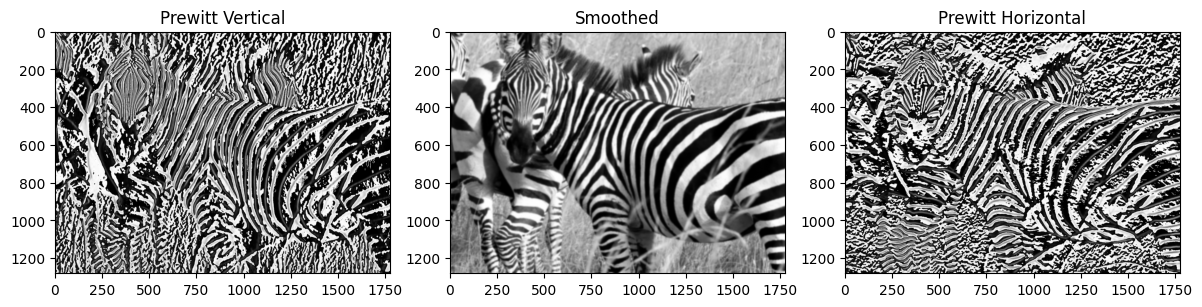

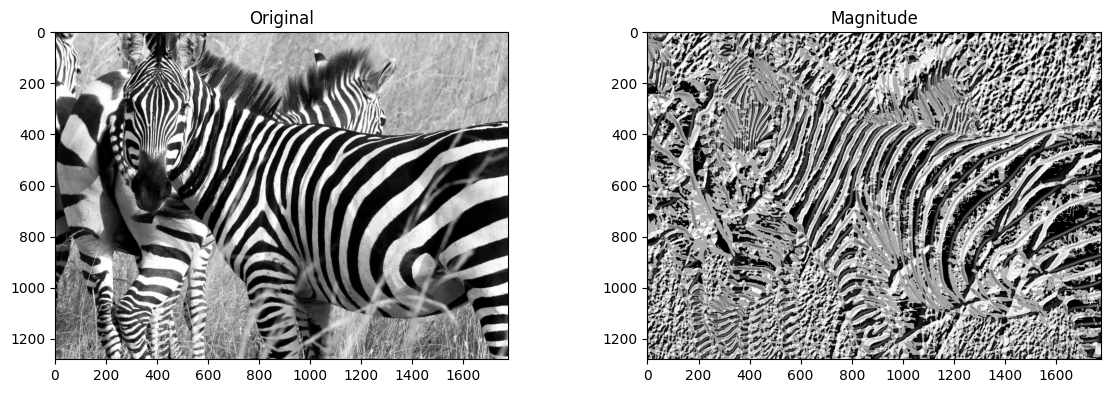

In [47]:
#low-pass Filtering
smoothed_img = scipy.ndimage.gaussian_filter(zebras, sigma=3)

# Prewitt operators
prewitt_v = scipy.ndimage.prewitt(smoothed_img, axis=1)  # horizontal kernel (detects horizontal edges)
prewitt_h = scipy.ndimage.prewitt(smoothed_img, axis=0)  # Horizontal kernel (detects horizontal edges)

# Combine gradients (magnitude)
prewitt_mag = np.hypot(prewitt_h, prewitt_v)

# Show results

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.title("Prewitt Vertical")
plt.imshow(prewitt_v, cmap='gray')

plt.subplot(1, 3, 2)
plt.title("Smoothed")
plt.imshow(smoothed_img, cmap='gray')

plt.subplot(1, 3, 3)
plt.title("Prewitt Horizontal")
plt.imshow(prewitt_h, cmap='gray')

plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.title("Original")
plt.imshow(zebras, cmap='gray')

plt.subplot(1, 2, 2)
plt.title("Magnitude")
plt.imshow(prewitt_mag, cmap='gray')

plt.tight_layout()
plt.show()

